<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Run 3: CORSIKA Event Generator with Height-Aware Primaries

This notebook runs CORSIKA 8 from the primary table generated by `run2_CosmicRay_SamplePrimaries.ipynb`.

The key difference from earlier event generators is that each primary row includes `observation_level_m`, which is passed to CORSIKA through `--observation-level` and stored in per-event metadata. This ensures the height coordinate is preserved for dataset construction.

## 1. Libraries

This section imports the tools required to build CORSIKA commands, launch subprocesses in parallel, track runtime, and summarize the resulting campaign manifest.

In [1]:
from __future__ import annotations
%matplotlib inline
import csv, os, shutil, shlex, subprocess, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

from tpeanuts.notebooks.notebookConfig import load_notebook_config
import tpeanuts.config.default as default

plt.style.use("seaborn-v0_8-whitegrid")



In [2]:
# Section 1 diagnostic: verify execution and plotting dependencies.
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Parallel execution tools imported: ThreadPoolExecutor, as_completed")
print("Matplotlib inline rendering is enabled in notebooks.")

assert np.__version__
assert plt is not None

print(f"\nMatplotlib inline rendering is enabled in notebooks.")
print(f"Configured style: seaborn-v0_8-whitegrid")

print("\nSection 1 test passed: libraries are available.")

Pandas version: 3.0.3
NumPy version: 2.4.5
Parallel execution tools imported: ThreadPoolExecutor, as_completed
Matplotlib inline rendering is enabled in notebooks.

Matplotlib inline rendering is enabled in notebooks.
Configured style: seaborn-v0_8-whitegrid

Section 1 test passed: libraries are available.


## 2. Paths and Configuration

Shared paths and run-level controls for the CORSIKA event campaign.


### 2.1 Paths

All workflow input and output paths are defined here from `load_notebook_config()`.


In [3]:
config = load_notebook_config()

PATH_CORSIKA_ROOT = "/home/juan/hep/opt/corsika8-install"
RUN = "run_test"

OUTPUT_ROOT = config.output_root
OUTPUT_DATA_ROOT = config.output_data_root
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the original notebook code.
PATH_OUTPUT_ROOT = OUTPUT_ROOT
PATH_OUTPUT_CORSIKA = OUTPUT_CORSIKA_ROOT
PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_CORSIKA_GENERATOR.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
OUTPUT_DIR = PATH_OUTPUT_RUN
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")
RECONSTRUCTED_MANIFEST_PATH = PATH_MANIFEST_FILE
PATH_DATASET_NEUTRINO_FILE = Path(PATH_OUTPUT_RUN / "dataset_neutrino_test.h5")
PATH_OUTPUT_RUN.mkdir(parents=True, exist_ok=True)

# run1_CosmicRay_Model.ipynb / run2_CosmicRay_SamplePrimaries.ipynb (CRF) write
# a per-execution seeded model/primaries pair under a separate "crf" output
# tree, using the same RUN label. Load the most recently generated pair so
# this notebook always consumes fresh CRF output instead of a stale filename.
PATH_CRF_RUN = Path(OUTPUT_DATA_ROOT / "crf" / "generator" / RUN)
_crf_models = sorted(PATH_CRF_RUN.glob("crf_model_*.h5"), key=lambda p: p.stat().st_mtime)
_crf_primaries = sorted(PATH_CRF_RUN.glob("crf_primary_*.csv"), key=lambda p: p.stat().st_mtime)
if not _crf_primaries:
    raise FileNotFoundError(
        f"No CRF primary table found in {PATH_CRF_RUN}. "
        "Run run1_CosmicRay_Model.ipynb and run2_CosmicRay_SamplePrimaries.ipynb first."
    )
PATH_CRMODEL_FILE = _crf_models[-1] if _crf_models else None
PATH_PRIMARIES_FILE = _crf_primaries[-1]

print(" Configured workflow paths:\n", "=" * 80)
print(" - PATH_CORSIKA_ROOT = ", PATH_CORSIKA_ROOT)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - RUN = ", RUN, "\n")

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_RUN       = ", PATH_OUTPUT_RUN)
print(" - OUTPUT_DIR            = ", OUTPUT_DIR)
print(" - PATH_MANIFEST_FILE    = ", PATH_MANIFEST_FILE)
print(" - PATH_DATASET_NEUTRINO_FILE  = ", PATH_DATASET_NEUTRINO_FILE)

print("\n CRF input paths (latest run):\n", "=" * 80)
print(" - PATH_CRF_RUN          = ", PATH_CRF_RUN)
print(" - PATH_CRMODEL_FILE     = ", PATH_CRMODEL_FILE)
print(" - PATH_PRIMARIES_FILE   = ", PATH_PRIMARIES_FILE, "(latest CRF primary table)")



 Configured workflow paths:
 - PATH_CORSIKA_ROOT =  /home/juan/hep/opt/corsika8-install
 - OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_DATA_ROOT =  /mnt/v/output/data
 - OUTPUT_CORSIKA_ROOT =  /mnt/v/output/data/corsika
 - RUN =  run_test 

 Output paths:
 - PATH_OUTPUT_RUN       =  /mnt/v/output/data/corsika/generator/run_test
 - OUTPUT_DIR            =  /mnt/v/output/data/corsika/generator/run_test
 - PATH_MANIFEST_FILE    =  /mnt/v/output/data/corsika/generator/run_test/manifest.csv
 - PATH_DATASET_NEUTRINO_FILE  =  /mnt/v/output/data/corsika/generator/run_test/dataset_neutrino_test.h5

 CRF input paths (latest run):
 - PATH_CRF_RUN          =  /mnt/v/output/data/crf/generator/run_test
 - PATH_CRMODEL_FILE     =  /mnt/v/output/data/crf/generator/run_test/crf_model_117074994.h5
 - PATH_PRIMARIES_FILE   =  /mnt/v/output/data/crf/generator/run_test/crf_primary_877549497.csv (latest CRF primary table)


### 2.2 Parameters and Configuration

Run controls, filtering thresholds, reconstruction options, and the execution dataclass.


In [4]:
PRIMARY_SPECIES: dict[int, dict[str, object]] = {
    14:   {"mnemonic": "p",    "name": "proton",      "Z": 1,  "A": 1,  "pdg": 2212},
    402:  {"mnemonic": "He",   "name": "helium",      "Z": 2,  "A": 4,  "pdg": 0},
    1206: {"mnemonic": "C",    "name": "carbon",      "Z": 6,  "A": 12, "pdg": 0},
    1407: {"mnemonic": "N",    "name": "nitrogen",    "Z": 7,  "A": 14, "pdg": 0},
    1608: {"mnemonic": "O",    "name": "oxygen",      "Z": 8,  "A": 16, "pdg": 0},
    2412: {"mnemonic": "Mg",   "name": "magnesium",   "Z": 12, "A": 24, "pdg": 0},
    2613: {"mnemonic": "Al",   "name": "aluminium",   "Z": 13, "A": 26, "pdg": 0},
    2814: {"mnemonic": "Si",   "name": "silicon",     "Z": 14, "A": 28, "pdg": 0},
    5025: {"mnemonic": "Mn",   "name": "manganese",   "Z": 25, "A": 50, "pdg": 0},
    5426: {"mnemonic": "Fe54", "name": "iron-54",     "Z": 26, "A": 54, "pdg": 0},
    5427: {"mnemonic": "Co54", "name": "cobalt-54",   "Z": 27, "A": 54, "pdg": 0},
    5626: {"mnemonic": "Fe56", "name": "iron-56",     "Z": 26, "A": 56, "pdg": 0},
}

# ==========================================================
# Configuration constants
# ==========================================================

START_INDEX = 0
MAX_EVENTS = None

Z_MAX = 25
MIN_ENERGY_PER_NUCLEON_GEV = 20.0
MAX_ENERGY_PRIMARY_GEV = 1e6

WORKERS = 12
EVENT_TIMEOUT_SECONDS = 3600

BASE_SEED = 42
VERBOSITY = "warn"
FORCE = False
WRITE_RECONSTRUCTED_MANIFEST = False
BACKUP_EXISTING_MANIFEST = True

# Hadronic-interaction-model name translation: CRFlux/MCEq spelling (as used
# by util.default.mceq_interaction_model and the atmosphere5 MCEq generation
# notebook) -> the `-M/--hadronModel` spelling accepted by CORSIKA8's
# `c8_tpeanuts` binary. Only covers models with a direct CORSIKA8 counterpart.
MCEQ_TO_CORSIKA_HADRON_MODEL = {
    "SIBYLL23D": "SIBYLL-2.3d",
    "QGSJETII04": "QGSJet-II.04",
    "QGSJETIII": "QGSJet-III",
    "EPOSLHC": "EPOS-LHC",
}
HADRON_MODEL = MCEQ_TO_CORSIKA_HADRON_MODEL[default.mceq_interaction_model]

@dataclass(frozen=True)
class Config:
    """Configuration for CORSIKA event execution.

    Args:
        primaries_path: Primary table produced by Run 2.
        output_root: Directory where event outputs and logs are written.
        manifest_path: CSV file collecting per-event execution status.
        corsika_root: CORSIKA installation prefix.
        start_index: First primary row to process.
        max_events: Optional cap on the number of events to run.
        workers: Number of parallel subprocess workers.
        event_timeout_seconds: Per-event wall-clock timeout.
        base_seed: Base random seed added to `event_id`.
        verbosity: CORSIKA verbosity level.
        force: Whether to overwrite existing event outputs.
    """

    primaries_path: Path = Path(PATH_PRIMARIES_FILE)
    output_root: Path = Path(PATH_OUTPUT_RUN)
    manifest_path: Path = Path(PATH_MANIFEST_FILE )
    corsika_root: Path = Path(PATH_CORSIKA_ROOT)
    start_index: int = 0
    max_events: int | None = None
    Z_max: int | None = 26
    min_energy_per_nucleon_gev: float | None = 20.0
    max_energy_primary: float | None = MAX_ENERGY_PRIMARY_GEV
    workers: int = 2
    event_timeout_seconds: int = 900
    base_seed: int = 100000
    verbosity: str = "warn"
    force: bool = False
    hadron_model: str = "SIBYLL-2.3d"

    @property
    def corsika_bin(self) -> Path:
        """Return the CORSIKA air-shower executable path.

        Returns:
            Full path to `c8_air_shower`.
        """
        return self.corsika_root / "bin" / "c8_tpeanuts"

# ==========================================================
# Config object
# ==========================================================

CONFIG = Config(
    primaries_path             = Path(PATH_PRIMARIES_FILE),
    output_root                = Path(PATH_OUTPUT_RUN),
    manifest_path              = Path(PATH_MANIFEST_FILE ),
    corsika_root               = Path(PATH_CORSIKA_ROOT),
    start_index                = START_INDEX,
    max_events                 = MAX_EVENTS,
    Z_max                      = Z_MAX,
    min_energy_per_nucleon_gev = MIN_ENERGY_PER_NUCLEON_GEV,
    max_energy_primary         = MAX_ENERGY_PRIMARY_GEV,
    workers                    = WORKERS,
    event_timeout_seconds      = EVENT_TIMEOUT_SECONDS,
    base_seed                  = BASE_SEED,
    verbosity                  = VERBOSITY,
    force                      = FORCE,
    hadron_model               = HADRON_MODEL,
)

if CONFIG.workers <= 0:
    raise ValueError("workers must be positive.")
if CONFIG.event_timeout_seconds <= 0:
    raise ValueError("event_timeout_seconds must be positive.")

print("CORSIKA event-generator configuration")
print("-" * 72)
for field_name in CONFIG.__dataclass_fields__:
    print(f"{field_name:>24}: {getattr(CONFIG, field_name)}")
print(f"{'corsika_bin':>24}: {CONFIG.corsika_bin}")

print("\nPrimary species catalog")
print("-" * 72)
for corsika_id, species in PRIMARY_SPECIES.items():
    print(
        f"CORSIKA ID {corsika_id:>4}: "
        f"{species['mnemonic']:<4} | {species['name']:<10} | "
        f"Z={species['Z']:>2} A={species['A']:>2} PDG={species['pdg']}"
    )


CORSIKA event-generator configuration
------------------------------------------------------------------------
          primaries_path: /mnt/v/output/data/crf/generator/run_test/crf_primary_877549497.csv
             output_root: /mnt/v/output/data/corsika/generator/run_test
           manifest_path: /mnt/v/output/data/corsika/generator/run_test/manifest.csv
            corsika_root: /home/juan/hep/opt/corsika8-install
             start_index: 0
              max_events: None
                   Z_max: 25
min_energy_per_nucleon_gev: 20.0
      max_energy_primary: 1000000.0
                 workers: 12
   event_timeout_seconds: 3600
               base_seed: 42
               verbosity: warn
                   force: False
            hadron_model: SIBYLL-2.3d
             corsika_bin: /home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts

Primary species catalog
------------------------------------------------------------------------
CORSIKA ID   14: p    | proton     | Z= 1 A= 1 PDG=22

In [5]:
# Section 2 diagnostic: show resolved executable and campaign destinations.
print(f"CORSIKA executable: {CONFIG.corsika_bin}")
print(f"Primaries file: {CONFIG.primaries_path}")
print(f"Output root: {CONFIG.output_root}")
print(f"Manifest: {CONFIG.manifest_path}")


CORSIKA executable: /home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts
Primaries file: /mnt/v/output/data/crf/generator/run_test/crf_primary_877549497.csv
Output root: /mnt/v/output/data/corsika/generator/run_test
Manifest: /mnt/v/output/data/corsika/generator/run_test/manifest.csv


## 3. Primary Table Loading

This section loads the sampled primary table from Run 2, applies the CORSIKA compatibility cuts, and converts the selected rows into immutable event objects used by the command builder.


### 3.1 Auxiliary Functions

This subsection defines the event/result data structures and helper functions used to load primary tables and convert table rows into CORSIKA event descriptions.


In [6]:
@dataclass(frozen=True)
class Event:
    """Primary event passed to one CORSIKA execution.

    Args:
        event_id: Integer event identifier.
        corsika_id: CORSIKA primary particle ID.
        z: Nuclear charge.
        a: Nuclear mass number.
        pdg: PDG code for proton primaries, otherwise zero.
        energy_gev: Primary energy in GeV.
        theta_deg: Primary zenith angle in degrees.
        phi_deg: Primary azimuth in degrees.
        observation_level_m: Observation-plane height in meters.
        primary_weight: Importance-corrected primary weight.
        mode: Primary injection mode, either `pdg` or `nucleus`.
        mnemonic: Short species label.
        name: Human-readable species name.
        p_real: Physical sampling probability at the primary state.
        q_sim: Proposal sampling probability at the primary state.
        importance_ratio: Ratio `p_real / q_sim`.
    """
    event_id: int; corsika_id: int; z: int; a: int; pdg: int
    energy_gev: float; theta_deg: float; phi_deg: float; observation_level_m: float
    primary_weight: float; mode: str; mnemonic: str; name: str
    p_real: float; q_sim: float; importance_ratio: float


@dataclass(frozen=True)
class Result:
    """Execution result for one CORSIKA event."""
    event_id: int; status: str; returncode: int; output_dir: Path; stdout_log: Path; stderr_log: Path; elapsed_seconds: float; command: str
    corsika_id: int; primary_mnemonic: str; primary_name: str; Z: int; A: int; pdg: int
    E0_GeV: float; theta0_deg: float; phi0_deg: float; observation_level_m: float
    primary_weight: float; p_real: float; q_sim: float; importance_ratio: float
    neutrino_total: int; neutrino_e: int; neutrino_mu: int; neutrino_tau: int


def load_table(path: Path) -> pd.DataFrame:
    """Load a primary table from CSV or Parquet.

    Args:
        path: Primary table path.

    Returns:
        DataFrame with sampled primary events.
    """
    return pd.read_csv(path) if path.suffix == ".csv" else pd.read_parquet(path)


def to_event(row) -> Event:
    """Convert one primary-table row into an `Event`.

    Args:
        row: Row object produced by `DataFrame.itertuples`.

    Returns:
        Immutable event description.
    """
    corsika_id = int(row.corsika_id)
    species = PRIMARY_SPECIES.get(corsika_id, {"mnemonic": str(corsika_id), "name": "unknown"})
    mnemonic = str(getattr(row, "species_mnemonic", species["mnemonic"]))
    name = str(getattr(row, "species_name", species["name"]))
    return Event(
        int(row.event_id), corsika_id, int(row.Z), int(row.A), int(row.pdg),
        float(row.E0_GeV), float(row.theta0_deg), float(row.phi0_deg),
        float(row.observation_level_m), float(row.primary_weight),
        str(row.corsika8_primary_mode), mnemonic, name,
        float(getattr(row, "p_real", np.nan)),
        float(getattr(row, "q_sim", np.nan)),
        float(getattr(row, "importance_ratio", np.nan)),
    )





### 3.2 Data Loading

This subsection reads the primary table configured in `CONFIG.primaries_path` and prints the number of rows before any compatibility or physics-motivated filtering is applied.


In [7]:
print(f"Loading primary File: {CONFIG.primaries_path}")
table_raw = load_table(CONFIG.primaries_path)
print(f"Loaded primary rows: {len(table_raw)}")
display(table_raw.head())


Loading primary File: /mnt/v/output/data/crf/generator/run_test/crf_primary_877549497.csv
Loaded primary rows: 1000000


,event_id,corsika_id,species_mnemonic,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,...,energy_bin_index,theta_bin_index,phi_bin_index,h_bin_index,p_real,q_sim,importance_ratio,primary_weight,sampling_mode,corsika8_primary_mode
0,0,14,p,1,1,2212,319.185706,63.683528,186.871252,93081.672321,...,126,64,187,187,2.045244e-10,2.045244e-10,1.0,0.000037,physical,pdg
1,1,1206,C,6,12,0,247.638350,67.774782,161.603936,80722.004393,...,98,68,162,162,3.711517e-11,3.711517e-11,1.0,0.000037,physical,nucleus
2,2,402,He,2,4,0,220.666802,41.620834,328.383806,3195.594452,...,86,42,329,6,1.685694e-10,1.685694e-10,1.0,0.000037,physical,nucleus
3,3,14,p,1,1,2212,367.168214,82.198035,232.479301,34601.638827,...,141,83,233,69,1.785388e-10,1.785388e-10,1.0,0.000037,physical,pdg
4,4,2814,Si,14,28,0,102.382679,47.199966,237.185344,15353.919274,...,2,47,237,30,1.171205e-10,1.171205e-10,1.0,0.000037,physical,nucleus


### 3.3 Data Filtering

This subsection filters the primary table using `CONFIG.Z_max` and `CONFIG.min_energy_per_nucleon_gev`. The energy-per-nucleon cut uses $E_0/A$ and is intended to remove low-energy heavy nuclei that are more likely to trigger unstable CORSIKA model configurations.


In [8]:
table = table_raw.copy()
filter_summary = []

if CONFIG.Z_max is not None:
    z_mask = table["Z"] <= CONFIG.Z_max
    rejected_z = table.loc[~z_mask].copy()
    print(f"Applying charge filter: Z <= {CONFIG.Z_max}")
    print(f"  Rows rejected by Z_max: {len(rejected_z):,}")
    if len(rejected_z):
        display(rejected_z[["event_id", "corsika_id", "species_mnemonic", "Z", "A", "E0_GeV"]].head(10))
    filter_summary.append({"filter": f"Z <= {CONFIG.Z_max}", "rows_before": len(table), "rows_rejected": len(rejected_z)})
    table = table.loc[z_mask].copy()

if CONFIG.max_energy_primary is not None:
    E0_max_mask = table["E0_GeV"] <= CONFIG.max_energy_primary
    rejected_E0_max = table.loc[~E0_max_mask].copy()
    print(f"Applying Max Energy Primary filter: E0_max  <= {CONFIG.max_energy_primary:.3g} GeV")
    print(f"  Rows rejected by E0_max: {len(rejected_E0_max):,}")
    if len(rejected_z):
        display(rejected_E0_max[["event_id", "corsika_id", "species_mnemonic", "Z", "A", "E0_GeV"]].head(10))
    filter_summary.append({"filter": f"E0_max <= {CONFIG.max_energy_primary:.3g}", "rows_before": len(table), "rows_rejected": len(rejected_E0_max)})
    table = table.loc[E0_max_mask].copy()

if CONFIG.min_energy_per_nucleon_gev is not None:
    table["E0_per_nucleon_GeV"] = table["E0_GeV"] / table["A"].replace(0, np.nan)
    epa_mask = table["E0_per_nucleon_GeV"] >= CONFIG.min_energy_per_nucleon_gev
    rejected_epa = table.loc[~epa_mask].copy()
    print(f"\nApplying energy-per-nucleon filter: E0/A >= {CONFIG.min_energy_per_nucleon_gev:.3g} GeV/nucleon")
    print(f"  Rows rejected by E0/A: {len(rejected_epa):,}")
    if len(rejected_epa):
        display(rejected_epa[["event_id", "corsika_id", "species_mnemonic", "Z", "A", "E0_GeV", "E0_per_nucleon_GeV"]].head(10))
    filter_summary.append({"filter": f"E0/A >= {CONFIG.min_energy_per_nucleon_gev:g} GeV", "rows_before": len(table), "rows_rejected": len(rejected_epa)})
    table = table.loc[epa_mask].copy()
elif "E0_per_nucleon_GeV" not in table.columns:
    table["E0_per_nucleon_GeV"] = table["E0_GeV"] / table["A"].replace(0, np.nan)

filter_summary = pd.DataFrame(filter_summary)
print("\nFiltering summary")
print("-" * 72)
if filter_summary.empty:
    print("No filters were applied.")
else:
    display(filter_summary)
print(f"Rows after filtering: {len(table):,}")

if table.empty:
    raise ValueError("No primary rows remain after filtering. Relax CONFIG.Z_max or CONFIG.min_energy_per_nucleon_gev.")


Applying charge filter: Z <= 25
  Rows rejected by Z_max: 83,506


,event_id,corsika_id,species_mnemonic,Z,A,E0_GeV
7,7,5426,Fe54,26,54,110.929127
12,12,5426,Fe54,26,54,469.167340
29,29,5426,Fe54,26,54,105.966515
41,41,5426,Fe54,26,54,358.123080
55,55,5426,Fe54,26,54,106.497005
65,65,5426,Fe54,26,54,184.847447
69,69,5426,Fe54,26,54,138.287070
90,90,5426,Fe54,26,54,104.576001
94,94,5426,Fe54,26,54,138.789526
95,95,5426,Fe54,26,54,280.037370


Applying Max Energy Primary filter: E0_max  <= 1e+06 GeV
  Rows rejected by E0_max: 0


,event_id,corsika_id,species_mnemonic,Z,A,E0_GeV



Applying energy-per-nucleon filter: E0/A >= 20 GeV/nucleon
  Rows rejected by E0/A: 194,059


,event_id,corsika_id,species_mnemonic,Z,A,E0_GeV,E0_per_nucleon_GeV
4,4,2814,Si,14,28,102.382679,3.656524
13,13,1608,O,8,16,213.414783,13.338424
25,25,1206,C,6,12,143.977623,11.998135
28,28,1608,O,8,16,100.867935,6.304246
30,30,2412,Mg,12,24,161.562034,6.731751
34,34,1206,C,6,12,140.043369,11.670281
36,36,1608,O,8,16,108.406073,6.775380
38,38,1608,O,8,16,157.629526,9.851845
42,42,5025,Mn,25,50,265.786039,5.315721
45,45,1206,C,6,12,111.522758,9.293563



Filtering summary
------------------------------------------------------------------------


,filter,rows_before,rows_rejected
0,Z <= 25,1000000,83506
1,E0_max <= 1e+06,916494,0
2,E0/A >= 20 GeV,916494,194059


Rows after filtering: 722,435


### 3.4 Checks, Validation, and Visualization

This subsection checks the filtered primary table, creates the final `events` list, and visualizes the selected phase-space coverage before the CORSIKA command builder is used.


Filtered primary rows available: 722,435
Configured start index         : 0
Existing manifest path         : /mnt/v/output/data/corsika/generator/run_test/manifest.csv
Last manifest event_id         : none
Rows after manifest pointer    : 722,435
Max events                     : None
Candidate event rows           : 722,435
Skipped existing outputs       : 0
Selected event rows to run     : 722,435
Missing expected columns       : none



,event_id,corsika_id,species_mnemonic,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,...,theta_bin_index,phi_bin_index,h_bin_index,p_real,q_sim,importance_ratio,primary_weight,sampling_mode,corsika8_primary_mode,E0_per_nucleon_GeV
0,0,14,p,1,1,2212,319.185706,63.683528,186.871252,93081.672321,...,64,187,187,2.045244e-10,2.045244e-10,1.0,0.000037,physical,pdg,319.185706
1,1,1206,C,6,12,0,247.638350,67.774782,161.603936,80722.004393,...,68,162,162,3.711517e-11,3.711517e-11,1.0,0.000037,physical,nucleus,20.636529
2,2,402,He,2,4,0,220.666802,41.620834,328.383806,3195.594452,...,42,329,6,1.685694e-10,1.685694e-10,1.0,0.000037,physical,nucleus,55.166701
3,3,14,p,1,1,2212,367.168214,82.198035,232.479301,34601.638827,...,83,233,69,1.785388e-10,1.785388e-10,1.0,0.000037,physical,pdg,367.168214
5,5,1608,O,8,16,0,463.344526,61.639774,248.030157,57918.604332,...,62,248,116,1.881727e-11,1.881727e-11,1.0,0.000037,physical,nucleus,28.959033


,E0_GeV,E0_per_nucleon_GeV,theta0_deg,observation_level_m,primary_weight,importance_ratio
count,722435.000000,722435.000000,722435.000000,722435.000000,7.224350e+05,722435.0
mean,269.226430,170.917060,56.736017,49974.724810,3.690354e-05,1.0
std,968.126292,583.898167,21.339369,28872.305160,1.355254e-20,0.0
min,100.000061,20.000993,0.094766,0.219059,3.690354e-05,1.0
25%,119.653441,45.333230,40.988310,24960.113768,3.690354e-05,1.0
50%,154.871125,116.271375,59.449303,49977.475579,3.690354e-05,1.0
75%,246.626135,174.728699,74.787551,74995.781347,3.690354e-05,1.0
max,258416.026968,163786.290303,88.999945,99999.560137,3.690354e-05,1.0


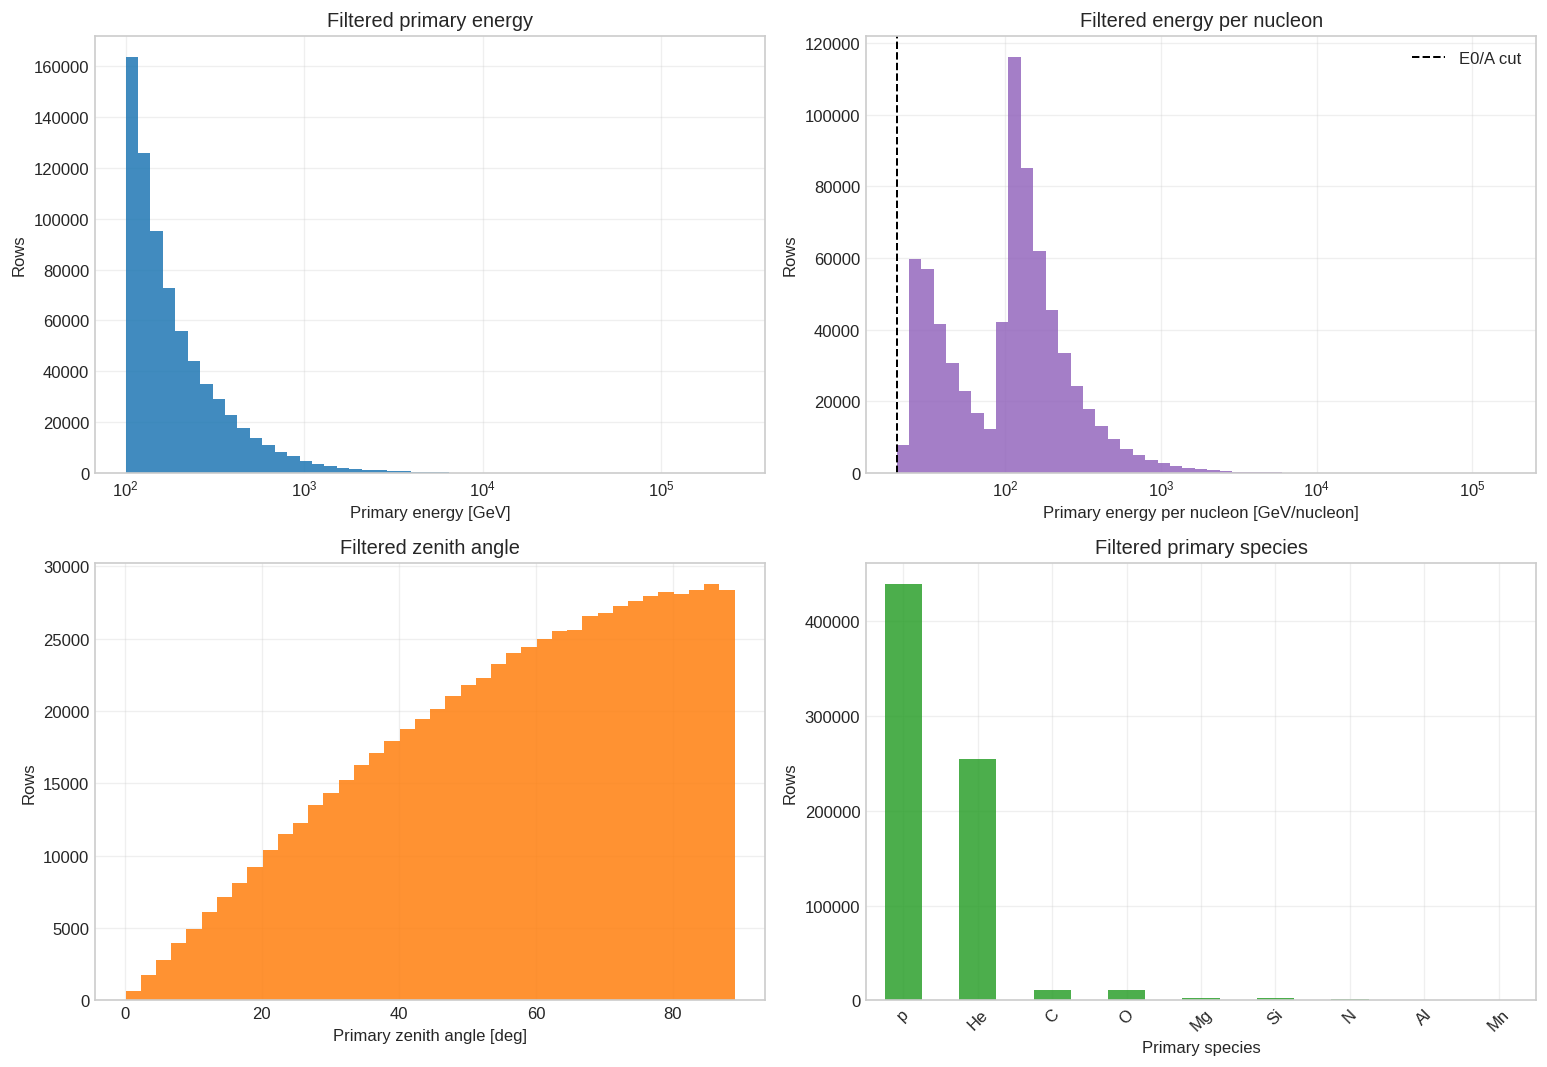

Section 3.4 test passed: filtered primary table is ready for CORSIKA event generation.


In [9]:
# Section 3 diagnostic: inspect selected primary phase-space coverage after filtering.
def last_manifest_event_id(path: Path) -> int | None:
    """Return the largest event_id already registered in the manifest, if any."""
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        manifest_events = pd.read_csv(path, usecols=["event_id"])
    except Exception as exc:
        raise RuntimeError(f"Cannot read existing manifest before event selection: {path}") from exc
    if manifest_events.empty:
        return None
    return int(manifest_events["event_id"].dropna().astype(int).max())


def event_output_exists(event: Event) -> bool:
    """Return True when this event already has an output directory."""
    return (CONFIG.output_root / f"event_{event.event_id:08d}").exists()


last_registered_event_id = last_manifest_event_id(CONFIG.manifest_path)
effective_table = table.iloc[CONFIG.start_index:].copy()
if last_registered_event_id is not None:
    effective_table = effective_table[effective_table["event_id"].astype(int) > last_registered_event_id].copy()

event_candidates = [to_event(row) for row in effective_table.itertuples(index=False)]
if CONFIG.max_events is not None:
    event_candidates = event_candidates[:CONFIG.max_events]

events = []
skipped_existing_events = []
for event in event_candidates:
    if event_output_exists(event) and not CONFIG.force:
        skipped_existing_events.append(event)
        print(
            f"Skipping event {event.event_id:08d}: output already exists at "
            f"{CONFIG.output_root / f'event_{event.event_id:08d}'}; manifest is not modified."
        )
    else:
        events.append(event)

print(f"Filtered primary rows available: {len(table):,}")
print(f"Configured start index         : {CONFIG.start_index}")
print(f"Existing manifest path         : {CONFIG.manifest_path}")
print(f"Last manifest event_id         : {last_registered_event_id if last_registered_event_id is not None else 'none'}")
print(f"Rows after manifest pointer    : {len(effective_table):,}")
print(f"Max events                     : {CONFIG.max_events}")
print(f"Candidate event rows           : {len(event_candidates):,}")
print(f"Skipped existing outputs       : {len(skipped_existing_events):,}")
print(f"Selected event rows to run     : {len(events):,}")

required_columns = [
    "event_id", "corsika_id", "species_mnemonic", "Z", "A", "E0_GeV",
    "E0_per_nucleon_GeV", "theta0_deg", "phi0_deg", "observation_level_m",
    "primary_weight", "p_real", "q_sim", "importance_ratio",
]
missing_columns = [col for col in required_columns if col not in table.columns]
print(f"Missing expected columns       : {missing_columns if missing_columns else 'none'}\n")
assert not missing_columns
if not events:
    print("No new events selected for generation after manifest and existing-output checks.")
assert np.all(table["Z"] <= CONFIG.Z_max) if CONFIG.Z_max is not None else True
assert np.all(table["E0_per_nucleon_GeV"] >= CONFIG.min_energy_per_nucleon_gev) if CONFIG.min_energy_per_nucleon_gev is not None else True

display(table.head())
display(table[["E0_GeV", "E0_per_nucleon_GeV", "theta0_deg", "observation_level_m", "primary_weight", "importance_ratio"]].describe())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

energy = table.loc[table["E0_GeV"] > 0, "E0_GeV"].dropna()
energy_bins = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 50)
axes[0, 0].hist(energy, bins=energy_bins, color="tab:blue", alpha=0.85)
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("Primary energy [GeV]")
axes[0, 0].set_ylabel("Rows")
axes[0, 0].set_title("Filtered primary energy")

energy_per_a = table.loc[table["E0_per_nucleon_GeV"] > 0, "E0_per_nucleon_GeV"].dropna()
energy_per_a_bins = np.logspace(np.log10(energy_per_a.min()), np.log10(energy_per_a.max()), 50)
axes[0, 1].hist(energy_per_a, bins=energy_per_a_bins, color="tab:purple", alpha=0.85)
axes[0, 1].set_xscale("log")
axes[0, 1].axvline(CONFIG.min_energy_per_nucleon_gev, color="black", linestyle="--", lw=1.2, label="E0/A cut") if CONFIG.min_energy_per_nucleon_gev is not None else None
axes[0, 1].set_xlabel("Primary energy per nucleon [GeV/nucleon]")
axes[0, 1].set_ylabel("Rows")
axes[0, 1].set_title("Filtered energy per nucleon")
axes[0, 1].legend()

axes[1, 0].hist(table["theta0_deg"].dropna(), bins=40, color="tab:orange", alpha=0.85)
axes[1, 0].set_xlabel("Primary zenith angle [deg]")
axes[1, 0].set_ylabel("Rows")
axes[1, 0].set_title("Filtered zenith angle")

species_counts = table["species_mnemonic"].fillna("unknown").value_counts()
species_counts.plot(kind="bar", ax=axes[1, 1], color="tab:green", alpha=0.85)
axes[1, 1].set_xlabel("Primary species")
axes[1, 1].set_ylabel("Rows")
axes[1, 1].set_title("Filtered primary species")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Section 3.4 test passed: filtered primary table is ready for CORSIKA event generation.")


## 4. CORSIKA Command Construction

This section prepares the runtime environment and constructs one CORSIKA command per primary event, preserving primary energy, direction, species, weight metadata, and observation height.

In [10]:
def env() -> dict[str, str]:
    """Build the environment variables used by CORSIKA.

    Returns:
        Environment dictionary with CORSIKA paths prepended.
    """
    e = os.environ.copy(); root = str(CONFIG.corsika_root)
    e["PATH"] = f"{root}/bin:" + e.get("PATH", "")
    e["LD_LIBRARY_PATH"] = f"{root}/lib:{root}/lib/corsika:" + e.get("LD_LIBRARY_PATH", "")
    e["PYTHIA8DATA"] = f"{root}/share/Pythia8/xmldoc"
    return e


def command(event: Event, out: Path, seed: int) -> list[str]:
    """Construct the CORSIKA command for one primary event.

    Args:
        event: Primary event description.
        out: Event output directory.
        seed: Random seed for this event.

    Returns:
        Command argument list suitable for `subprocess.run`.
    """
    cmd = [
        str(CONFIG.corsika_bin),
        "-E", f"{event.energy_gev:.12g}",
        "-z", f"{event.theta_deg:.12g}",
        "-a", f"{event.phi_deg:.12g}",
        "-M", CONFIG.hadron_model,
        "--observation-level", f"{event.observation_level_m:.6g}",
        "--track-neutrinos",
        "-N", "1",
        "-s", str(seed),
        "--verbosity", CONFIG.verbosity,
        "-f", str(out),
    ]
    if event.mode == "pdg" and event.pdg:
        cmd[1:1] = ["--pdg", str(event.pdg)]
    else:
        cmd[1:1] = ["-Z", str(event.z), "-A", str(event.a)]
    return cmd


print("Example:")
if events:
    print(" ".join(shlex.quote(x) for x in command(events[0], CONFIG.output_root / f"event_{events[0].event_id:08d}", CONFIG.base_seed + events[0].event_id)))
else:
    print("No new event selected; command example is skipped.")


Example:
/home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts --pdg 2212 -E 319.185705513 -z 63.6835279062 -a 186.871251962 -M SIBYLL-2.3d --observation-level 93081.7 --track-neutrinos -N 1 -s 42 --verbosity warn -f /mnt/v/output/data/corsika/generator/run_test/event_00000000


In [11]:
# Section 4 diagnostic: verify the command contains height and neutrino tracking flags.
if events:
    example_cmd = command(events[0], CONFIG.output_root / f"event_{events[0].event_id:08d}", CONFIG.base_seed + events[0].event_id)
    print("--observation-level" in example_cmd, "--track-neutrinos" in example_cmd)
    print(f"Command argument count: {len(example_cmd)}")
else:
    print("No new event selected; command diagnostic is skipped.")


True True
Command argument count: 22


## 5. Event Execution

This section executes CORSIKA events in parallel, applies a per-event timeout, writes primary metadata, stores logs, and appends each result to the campaign manifest.

In [ ]:
NEUTRINO_PRODUCTION_PDG = {
    12: "e", -12: "e",
    14: "mu", -14: "mu",
    16: "tau", -16: "tau",
}


def summarize_produced_neutrinos(event_dir: Path) -> dict[str, int]:
    """Count neutrinos produced by the TPEANUTS writer for one event.

    Args:
        event_dir: CORSIKA event output directory.

    Returns:
        Counts for total, electron, muon, and tau neutrinos.
    """
    path = event_dir / "tpeanuts" / "neutrino_production.parquet"
    counts = {"neutrino_total": 0, "neutrino_e": 0, "neutrino_mu": 0, "neutrino_tau": 0}
    if not path.exists():
        return counts
    neutrinos = pd.read_parquet(path, columns=["neutrino_pdg"])
    counts["neutrino_total"] = int(len(neutrinos))
    flavors = neutrinos["neutrino_pdg"].map(NEUTRINO_PRODUCTION_PDG)
    counts["neutrino_e"] = int((flavors == "e").sum())
    counts["neutrino_mu"] = int((flavors == "mu").sum())
    counts["neutrino_tau"] = int((flavors == "tau").sum())
    return counts


def make_result(event: Event, status: str, returncode: int, out: Path, stdout: Path, stderr: Path, elapsed: float, command_text: str) -> Result:
    """Create a manifest result row with primary metadata and neutrino counts."""
    counts = summarize_produced_neutrinos(out) if status in {"done", "skipped_done"} else {"neutrino_total": 0, "neutrino_e": 0, "neutrino_mu": 0, "neutrino_tau": 0}
    return Result(
        event.event_id, status, returncode, out, stdout, stderr, elapsed, command_text,
        event.corsika_id, event.mnemonic, event.name, event.z, event.a, event.pdg,
        event.energy_gev, event.theta_deg, event.phi_deg, event.observation_level_m,
        event.primary_weight, event.p_real, event.q_sim, event.importance_ratio,
        counts["neutrino_total"], counts["neutrino_e"], counts["neutrino_mu"], counts["neutrino_tau"],
    )


def run_one(event: Event) -> Result | None:
    """Run one CORSIKA event with timeout and bookkeeping.

    Args:
        event: Primary event to simulate.

    Returns:
        Execution result with status, logs, output directory, and runtime, or None when skipped.
    """
    out = CONFIG.output_root / f"event_{event.event_id:08d}"
    logs = CONFIG.output_root / "_logs" / f"event_{event.event_id:08d}"
    meta = CONFIG.output_root / "_primaries"
    status = CONFIG.output_root / "_status"
    done = out / "corsika.done"
    failed = status / f"event_{event.event_id:08d}.failed"
    timeout_marker = status / f"event_{event.event_id:08d}.timeout"
    stdout = logs / "stdout.log"; stderr = logs / "stderr.log"
    seed = CONFIG.base_seed + event.event_id
    cmd = command(event, out, seed)
    text = " ".join(shlex.quote(x) for x in cmd)
    if out.exists() and not CONFIG.force:
        print(f"Skipping event {event.event_id:08d}: output already exists at {out}; manifest is not modified.")
        return None
    logs.mkdir(parents=True, exist_ok=True); meta.mkdir(parents=True, exist_ok=True); status.mkdir(parents=True, exist_ok=True)
    if failed.exists(): failed.unlink()
    if timeout_marker.exists(): timeout_marker.unlink()
    if CONFIG.force and out.exists(): shutil.rmtree(out)
    with (meta / f"event_{event.event_id:08d}.csv").open("w", newline="", encoding="utf-8") as h:
        w = csv.writer(h)
        w.writerow(["event_id","corsika_id","primary_mnemonic","primary_name","Z","A","pdg","E0_GeV","theta0_deg","phi0_deg","observation_level_m","primary_weight","p_real","q_sim","importance_ratio","seed"])
        w.writerow([event.event_id,event.corsika_id,event.mnemonic,event.name,event.z,event.a,event.pdg,event.energy_gev,event.theta_deg,event.phi_deg,event.observation_level_m,event.primary_weight,event.p_real,event.q_sim,event.importance_ratio,seed])
    start = time.monotonic()
    try:
        with stdout.open("w") as so, stderr.open("w") as se:
            p = subprocess.run(
                cmd,
                cwd=str(CONFIG.output_root),
                env=env(),
                stdout=so,
                stderr=se,
                text=True,
                timeout=CONFIG.event_timeout_seconds,
                check=False,
            )
        elapsed = time.monotonic() - start
        if p.returncode == 0:
            done.write_text(f"done\nevent_id={event.event_id}\nseed={seed}\nobservation_level_m={event.observation_level_m}\n")
            st = "done"
        else:
            failed.write_text(f"failed\nreturncode={p.returncode}\n")
            st = "failed"
        return make_result(event, st, p.returncode, out, stdout, stderr, elapsed, text)
    except subprocess.TimeoutExpired:
        elapsed = time.monotonic() - start
        with stderr.open("a", encoding="utf-8") as se:
            se.write(f"\nTIMEOUT: event exceeded {CONFIG.event_timeout_seconds} seconds and was discarded.\n")
        timeout_marker.write_text(
            f"timeout\nevent_id={event.event_id}\nseed={seed}\ntimeout_seconds={CONFIG.event_timeout_seconds}\nelapsed_seconds={elapsed:.3f}\n",
            encoding="utf-8",
        )
        if out.exists():
            shutil.rmtree(out)
        return make_result(event, "timeout", -124, out, stdout, stderr, elapsed, text)

def path_relative_to_output(path: str | Path) -> str:
    """Return a path relative to PATH_OUTPUT_CORSIKA when it belongs to that tree."""
    path = Path(path)
    try:
        return path.resolve().relative_to(PATH_OUTPUT_CORSIKA.resolve()).as_posix()
    except (ValueError, OSError):
        text = str(path).replace("\\", "/")
        for root_text in [
            str(PATH_OUTPUT_CORSIKA).replace("\\", "/"),
            str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
            str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
            str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
            str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
        ]:
            if text.lower().startswith(root_text.lower().rstrip("/") + "/"):
                return text[len(root_text.rstrip("/")) + 1:]
        return text
  
def metadata_text_relative_to_output(value):
    """Relativize OUTPUT_CORSIKA_ROOT paths embedded in metadata strings."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return value
    text = str(value).replace("\\", "/")
    for root_text in [
        str(PATH_OUTPUT_CORSIKA).replace("\\", "/"),
        str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
        str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
        str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
        str(OUTPUT_CORSIKA_ROOT).replace("\\", "/"),
    ]:
        root_clean = root_text.rstrip("/")
        text = text.replace(root_clean + "/", "")
        text = text.replace(root_clean, ".")
    return text.lstrip("./")
            
def append_manifest(path: Path, rows: Iterable[Result]) -> None:
    """Append event results to the manifest CSV while preserving old rows.

    Args:
        path: Manifest destination.
        rows: Iterable of event execution results.

    Returns:
        None. The file is created if it does not exist.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    new_rows = pd.DataFrame([r.__dict__ for r in rows])
    for column in ["output_dir", "stdout_log", "stderr_log"]:
        if column in new_rows.columns:
            new_rows[column] = new_rows[column].map(path_relative_to_output)
    if "command" in new_rows.columns:
        new_rows["command"] = new_rows["command"].map(metadata_text_relative_to_output)
    preferred_columns = list(Result.__dataclass_fields__)
    if path.exists() and path.stat().st_size > 0:
        existing = pd.read_csv(path)
        combined = pd.concat([existing, new_rows], ignore_index=True, sort=False)
    else:
        combined = new_rows
    for column in ["output_dir", "stdout_log", "stderr_log"]:
        if column in combined.columns:
            combined[column] = combined[column].map(path_relative_to_output)
    if "command" in combined.columns:
        combined["command"] = combined["command"].map(metadata_text_relative_to_output)
    remaining_columns = [col for col in combined.columns if col not in preferred_columns]
    combined = combined[[col for col in preferred_columns if col in combined.columns] + remaining_columns]
    combined.to_csv(path, index=False)


CONFIG.output_root.mkdir(parents=True, exist_ok=True)
done = []
print(f"Running {len(events)} events with workers={CONFIG.workers} and timeout={CONFIG.event_timeout_seconds}s per event.")
if events:
    with ThreadPoolExecutor(max_workers=CONFIG.workers) as ex:
        futures = [ex.submit(run_one, ev) for ev in events]
        for fut in as_completed(futures):
            r = fut.result()
            if r is None:
                continue
            done.append(r)
            append_manifest(CONFIG.manifest_path, [r])
            print(f"[{len(done):05d}/{len(events)}] event={r.event_id:05d} | "
                  f"status={r.status} | elapsed={r.elapsed_seconds:.1f}s |"
                  f"energy={r.E0_GeV:.1f} GeV | theta={r.theta0_deg:.1f}deg |"
                  f"neutrinos={r.neutrino_total}")
else:
    print("No new events to run; manifest is unchanged.")
print("Finished", len(done))
if done:
    print(pd.Series([r.status for r in done]).value_counts())
else:
    print("No event results were appended to the manifest.")


Running 722435 events with workers=12 and timeout=3600s per event.
[00001/722435] event=00006 | status=failed | elapsed=11.7s |energy=153.6 GeV | theta=71.8deg |neutrinos=0
[00002/722435] event=00014 | status=done | elapsed=11.7s |energy=117.6 GeV | theta=43.7deg |neutrinos=0
[00003/722435] event=00002 | status=done | elapsed=11.6s |energy=220.7 GeV | theta=41.6deg |neutrinos=0
[00004/722435] event=00003 | status=done | elapsed=11.7s |energy=367.2 GeV | theta=82.2deg |neutrinos=28
[00005/722435] event=00015 | status=failed | elapsed=11.7s |energy=108.5 GeV | theta=56.4deg |neutrinos=0
[00006/722435] event=00005 | status=failed | elapsed=11.7s |energy=463.3 GeV | theta=61.6deg |neutrinos=0
[00007/722435] event=00008 | status=done | elapsed=12.6s |energy=146.0 GeV | theta=60.7deg |neutrinos=40
[00008/722435] event=00011 | status=done | elapsed=13.0s |energy=130.2 GeV | theta=49.4deg |neutrinos=36
[00009/722435] event=00000 | status=failed | elapsed=11.7s |energy=319.2 GeV | theta=63.7deg

In [ ]:
# Section 5 diagnostic: summarize runtimes from this execution batch.
if done:
    batch = pd.DataFrame([r.__dict__ for r in done])
    display(batch[["event_id", "status", "returncode", "elapsed_seconds"]])
    print(batch.groupby("status")["elapsed_seconds"].describe())


## 6. Output Check and Manifest Recovery

This section checks whether the campaign manifest is consistent with the primary table and the event folders found in `PATH_DATASET_CORSIKA`. It also provides a controlled reconstruction routine for cases where `manifest.csv` is missing or corrupted.


### 6.1 Manifest Consistency Check

This subsection verifies that the manifest can be loaded, contains the expected columns, has no duplicated `event_id` rows, and is consistent with both the primary table and the event folders available in the output directory. It does not modify any file.


In [ ]:
def load_manifest_safely(path: Path) -> tuple[pd.DataFrame | None, str | None]:
    """Load a manifest CSV and return either the table or a readable error message."""
    if not path.exists():
        return None, f"Manifest file does not exist: {path}"
    try:
        return pd.read_csv(path), None
    except Exception as exc:
        return None, f"Manifest could not be read: {type(exc).__name__}: {exc}"


def list_event_folder_ids(output_root: Path) -> set[int]:
    """Return event ids found as event_XXXXXXXX directories in the campaign folder."""
    ids = set()
    if not output_root.exists():
        return ids
    for path in output_root.glob("event_[0-9]" * 0 + "event_*"):
        if path.is_dir():
            suffix = path.name.replace("event_", "")
            if suffix.isdigit():
                ids.add(int(suffix))
    return ids


def list_status_marker_ids(output_root: Path, suffix: str) -> set[int]:
    """Return event ids found in `_status/event_XXXXXXXX.<suffix>` files."""
    ids = set()
    status_dir = output_root / "_status"
    if not status_dir.exists():
        return ids
    for path in status_dir.glob(f"event_*.{suffix}"):
        stem = path.name.split(".", 1)[0]
        event_part = stem.replace("event_", "")
        if event_part.isdigit():
            ids.add(int(event_part))
    return ids


primary_table_for_check = load_table(CONFIG.primaries_path)
primary_ids = set(primary_table_for_check["event_id"].astype(int))
folder_ids = list_event_folder_ids(CONFIG.output_root)
failed_marker_ids = list_status_marker_ids(CONFIG.output_root, "failed")
timeout_marker_ids = list_status_marker_ids(CONFIG.output_root, "timeout")
marker_ids = failed_marker_ids | timeout_marker_ids
manifest_table, manifest_error = load_manifest_safely(CONFIG.manifest_path)

print("Manifest consistency check")
print("-" * 72)
print(f"Primary table path : {CONFIG.primaries_path}")
print(f"Output root        : {CONFIG.output_root}")
print(f"Manifest path      : {CONFIG.manifest_path}")
print(f"Primary rows       : {len(primary_table_for_check):,}")
print(f"Event folders      : {len(folder_ids):,}")
print(f"Failed markers     : {len(failed_marker_ids):,}")
print(f"Timeout markers    : {len(timeout_marker_ids):,}")

if manifest_error:
    print(f"Manifest status    : NOT OK - {manifest_error}")
else:
    required_columns = list(Result.__dataclass_fields__)
    missing_columns = [col for col in required_columns if col not in manifest_table.columns]
    manifest_ids = set(manifest_table["event_id"].astype(int)) if "event_id" in manifest_table.columns else set()
    duplicate_count = int(manifest_table.duplicated("event_id").sum()) if "event_id" in manifest_table.columns else np.nan
    print("Manifest status    : readable")
    print(f"Manifest rows      : {len(manifest_table):,}")
    print(f"Manifest event ids : {len(manifest_ids):,}")
    print(f"Duplicate event_id : {duplicate_count}")
    print(f"Missing columns    : {missing_columns if missing_columns else 'none'}")
    print(f"Manifest not in primaries : {len(manifest_ids - primary_ids):,}")
    print(f"Folders not in manifest   : {len(folder_ids - manifest_ids):,}")
    print(f"Markers not in manifest   : {len(marker_ids - manifest_ids):,}")
    print(f"Manifest rows without event folder or marker: {len(manifest_ids - folder_ids - marker_ids):,}")
    display(manifest_table.tail())

check_rows = pd.DataFrame(
    [
        {"source": "primaries", "n_event_ids": len(primary_ids)},
        {"source": "event_folders", "n_event_ids": len(folder_ids)},
        {"source": "failed_markers", "n_event_ids": len(failed_marker_ids)},
        {"source": "timeout_markers", "n_event_ids": len(timeout_marker_ids)},
        {"source": "manifest", "n_event_ids": 0 if manifest_table is None or "event_id" not in manifest_table else manifest_table["event_id"].nunique()},
    ]
)
display(check_rows)


### 6.2 Manifest Reconstruction

This subsection rebuilds `manifest.csv` from the primary table and the files present in `PATH_DATASET_CORSIKA`. The reconstruction uses `corsika.done`, `_status/*.failed`, `_status/*.timeout`, log paths, and TPEANUTS neutrino-production files. If `WRITE_RECONSTRUCTED_MANIFEST` is `True`, the existing manifest is backed up before being replaced.


In [ ]:
def parse_key_value_file(path: Path) -> dict[str, str]:
    """Parse simple key=value marker files into a dictionary."""
    values = {}
    if not path.exists():
        return values
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if "=" in line:
            key, value = line.split("=", 1)
            values[key.strip()] = value.strip()
    return values


def parse_failed_returncode(path: Path) -> int:
    """Read a return code from an `_status/*.failed` marker when possible."""
    values = parse_key_value_file(path)
    try:
        return int(values.get("returncode", "-999"))
    except ValueError:
        return -999


def infer_reconstructed_status(event_id: int, output_root: Path) -> tuple[str, int, float]:
    """Infer event status, return code, and elapsed seconds from output files."""
    event_dir = output_root / f"event_{event_id:08d}"
    status_dir = output_root / "_status"
    done_marker = event_dir / "corsika.done"
    failed_marker = status_dir / f"event_{event_id:08d}.failed"
    timeout_marker = status_dir / f"event_{event_id:08d}.timeout"

    if done_marker.exists():
        return "done", 0, np.nan
    if timeout_marker.exists():
        values = parse_key_value_file(timeout_marker)
        elapsed = float(values.get("elapsed_seconds", np.nan)) if values else np.nan
        return "timeout", -124, elapsed
    if failed_marker.exists():
        return "failed", parse_failed_returncode(failed_marker), np.nan
    if event_dir.exists():
        return "skipped_existing_no_done", 0, np.nan
    return "not_started", np.nan, np.nan


def command_from_primary_row(row: pd.Series, output_root: Path) -> str:
    """Recreate the CORSIKA command text from a primary-table row."""
    event_id = int(row["event_id"])
    out = output_root / f"event_{event_id:08d}"
    seed = CONFIG.base_seed + event_id
    mode = str(row.get("corsika8_primary_mode", "nucleus"))
    cmd = [
        str(CONFIG.corsika_bin),
        "-E", f"{float(row['E0_GeV']):.12g}",
        "-z", f"{float(row['theta0_deg']):.12g}",
        "-a", f"{float(row['phi0_deg']):.12g}",
        "-M", CONFIG.hadron_model,
        "--observation-level", f"{float(row['observation_level_m']):.6g}",
        "--track-neutrinos",
        "-N", "1",
        "-s", str(seed),
        "--verbosity", CONFIG.verbosity,
        "-f", str(out),
    ]
    if mode == "pdg" and int(row.get("pdg", 0)):
        cmd[1:1] = ["--pdg", str(int(row["pdg"]))]
    else:
        cmd[1:1] = ["-Z", str(int(row["Z"])), "-A", str(int(row["A"]))]
    return " ".join(shlex.quote(str(x)) for x in cmd)


def reconstruct_manifest_from_outputs(primary_table: pd.DataFrame, output_root: Path) -> pd.DataFrame:
    """Rebuild manifest rows from primaries, event folders, status markers, and logs."""
    rows = []
    event_folder_ids = list_event_folder_ids(output_root)
    marker_ids = list_status_marker_ids(output_root, "failed") | list_status_marker_ids(output_root, "timeout")
    candidate_ids = event_folder_ids | marker_ids
    primary_subset = primary_table[primary_table["event_id"].astype(int).isin(candidate_ids)].copy()

    for _, row in primary_subset.sort_values("event_id").iterrows():
        event_id = int(row["event_id"])
        event_dir = output_root / f"event_{event_id:08d}"
        log_dir = output_root / "_logs" / f"event_{event_id:08d}"
        stdout_log = log_dir / "stdout.log"
        stderr_log = log_dir / "stderr.log"
        status, returncode, elapsed_seconds = infer_reconstructed_status(event_id, output_root)
        species = PRIMARY_SPECIES.get(int(row["corsika_id"]), {"mnemonic": str(row["corsika_id"]), "name": "unknown"})
        counts = summarize_produced_neutrinos(event_dir) if status == "done" else {"neutrino_total": 0, "neutrino_e": 0, "neutrino_mu": 0, "neutrino_tau": 0}
        rows.append(
            {
                "event_id": event_id,
                "status": status,
                "returncode": returncode,
                "output_dir": path_relative_to_output(event_dir),
                "stdout_log": path_relative_to_output(stdout_log),
                "stderr_log": path_relative_to_output(stderr_log),
                "elapsed_seconds": elapsed_seconds,
                "command": command_from_primary_row(row, output_root),
                "corsika_id": int(row["corsika_id"]),
                "primary_mnemonic": str(row.get("species_mnemonic", species["mnemonic"])),
                "primary_name": str(species["name"]),
                "Z": int(row["Z"]),
                "A": int(row["A"]),
                "pdg": int(row["pdg"]),
                "E0_GeV": float(row["E0_GeV"]),
                "theta0_deg": float(row["theta0_deg"]),
                "phi0_deg": float(row["phi0_deg"]),
                "observation_level_m": float(row["observation_level_m"]),
                "primary_weight": float(row["primary_weight"]),
                "p_real": float(row.get("p_real", np.nan)),
                "q_sim": float(row.get("q_sim", np.nan)),
                "importance_ratio": float(row.get("importance_ratio", np.nan)),
                "neutrino_total": counts["neutrino_total"],
                "neutrino_e": counts["neutrino_e"],
                "neutrino_mu": counts["neutrino_mu"],
                "neutrino_tau": counts["neutrino_tau"],
            }
        )
    manifest = pd.DataFrame(rows)
    preferred_columns = list(Result.__dataclass_fields__)
    return manifest[[col for col in preferred_columns if col in manifest.columns]]


primary_table_for_rebuild = load_table(CONFIG.primaries_path)
reconstructed_manifest = reconstruct_manifest_from_outputs(primary_table_for_rebuild, CONFIG.output_root)

print("Reconstructed manifest preview")
print("-" * 72)
print(f"Rows reconstructed: {len(reconstructed_manifest):,}")
if not reconstructed_manifest.empty:
    display(reconstructed_manifest["status"].value_counts(dropna=False).rename_axis("status").to_frame("events"))
    display(reconstructed_manifest.head())
    display(reconstructed_manifest.tail())
else:
    print("No event folders or status markers were found to reconstruct from.")

if WRITE_RECONSTRUCTED_MANIFEST:
    RECONSTRUCTED_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    if BACKUP_EXISTING_MANIFEST and RECONSTRUCTED_MANIFEST_PATH.exists():
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        backup_path = RECONSTRUCTED_MANIFEST_PATH.with_name(f"{RECONSTRUCTED_MANIFEST_PATH.stem}.backup_{timestamp}{RECONSTRUCTED_MANIFEST_PATH.suffix}")
        shutil.copy2(RECONSTRUCTED_MANIFEST_PATH, backup_path)
        print(f"Existing manifest backed up to: {backup_path}")
    reconstructed_manifest.to_csv(RECONSTRUCTED_MANIFEST_PATH, index=False)
    print(f"Reconstructed manifest written to: {RECONSTRUCTED_MANIFEST_PATH}")
else:
    print("WRITE_RECONSTRUCTED_MANIFEST is False; no manifest file was written.")
